# Task 4 — Optimize Portfolio Based on Forecast

**Goal:** Combine the Task 3 TSLA forecast with historical BND/SPY data to construct an
optimal portfolio using Modern Portfolio Theory (MPT) — the mathematical framework for
assembling a portfolio that maximizes expected return for a given level of risk.

This notebook assumes `data/processed/combined_prices.csv` exists (Task 1). It re-derives the
Task 2/3 ARIMA order and future forecast internally (same pattern used in Task 3's notebook)
so it can run standalone, without needing to persist intermediate artifacts between notebooks.


In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.modeling import chronological_split, select_arima_order, forecast_future
from src.portfolio import (
    build_expected_returns, tsla_forecast_annual_return_from_prices,
    compute_covariance_matrix, portfolio_performance, sharpe_ratio_for_weights,
    optimize_max_sharpe, optimize_min_volatility, compute_efficient_frontier,
    random_portfolios, plot_covariance_heatmap, plot_efficient_frontier,
)

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.dpi"] = 100
RISK_FREE_RATE = 0.02   # consistent with the rate used in Task 1's Sharpe Ratio calculation


## 1. Load Data

In [2]:
df = pd.read_csv("../data/processed/combined_prices.csv", parse_dates=["Date"])
df = df.dropna(subset=["Daily_Return"]).reset_index(drop=True)
print(df.groupby("Ticker")["Date"].agg(["min", "max", "count"]))


              min        max  count
Ticker                             
BND    2015-01-05 2026-06-29   2887
SPY    2015-01-05 2026-06-29   2887
TSLA   2015-01-05 2026-06-29   2887


## 2. Prepare Expected Returns

Per the task instructions: TSLA's expected return comes from the Task 2/3 forecast (not
historical average — that's the whole point of having a forecast-informed "view"), while
BND and SPY use their historical average daily returns, annualized, as the proxy for
expected return.


### 2.1 Recover the TSLA Forecast (from Task 2/3)

In [3]:
tsla = df[df["Ticker"] == "TSLA"][["Date", "Close"]].reset_index(drop=True)
tsla_series = tsla.set_index("Date")["Close"]

SPLIT_DATE = "2025-01-01"
train_df, test_df = chronological_split(tsla, split_date=SPLIT_DATE, date_col="Date")

selection = select_arima_order(
    train_df.set_index("Date")["Close"], seasonal=False, max_p=5, max_q=5, max_d=2,
)
ORDER, SEASONAL_ORDER = selection["order"], selection["seasonal_order"]
print(f"Carrying forward ARIMA order: {ORDER} (AIC={selection['aic']:.2f})")

N_FUTURE_DAYS = 180  # matches Task 3's forecast horizon (~8-9 months, within the 6-12 month window)
future_forecast = forecast_future(
    tsla_series, order=ORDER, seasonal_order=SEASONAL_ORDER, n_periods=N_FUTURE_DAYS, alpha=0.05,
)

current_price = tsla_series.iloc[-1]
forecast_price = future_forecast["forecast"].iloc[-1]
print(f"Current TSLA price:  ${current_price:.2f}")
print(f"Forecast TSLA price (day {N_FUTURE_DAYS}): ${forecast_price:.2f}")


Carrying forward ARIMA order: (0, 1, 0) (AIC=16362.59)
Current TSLA price:  $411.84
Forecast TSLA price (day 180): $411.84


c:\Users\loolt\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\loolt\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\loolt\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


### 2.2 Convert the Price Forecast into an Expected Annual Return

The forecast gives a future *price*; MPT needs an expected *annual return*. We convert the
point-forecast's implied total return over the forecast horizon into an annualized (CAGR-style)
rate, so it's on the same footing as BND's/SPY's historical annualized returns.


In [5]:
tsla_forecast_annual_return = tsla_forecast_annual_return_from_prices(
    current_price=current_price, forecast_price=forecast_price, horizon_days=N_FUTURE_DAYS,
)
print(f"TSLA forecast-implied annualized expected return: {tsla_forecast_annual_return:.2%}")
print(f"Current price:  {current_price:.4f}")
print(f"Forecast price: {forecast_price:.4f}")
print(f"Raw annualized return: {tsla_forecast_annual_return}")


TSLA forecast-implied annualized expected return: 0.00%
Current price:  411.8400
Forecast price: 411.8400
Raw annualized return: 0.0


**A note of caution before proceeding:** this number carries forward all of Task 3's
uncertainty — recall the confidence interval around this point forecast widened substantially
over the horizon. Treat this as the "view" the analyst is taking, per the task's framing, not as
a confident guarantee. Section 6's recommendation revisits this limitation.


### 2.3 Build the Full Expected-Returns Vector

In [6]:
expected_returns = build_expected_returns(
    df, tsla_forecast_annual_return=tsla_forecast_annual_return, forecast_ticker="TSLA",
)
print("Expected annual returns (TSLA = forecast-derived, BND/SPY = historical average):")
expected_returns


Expected annual returns (TSLA = forecast-derived, BND/SPY = historical average):


BND    0.0200
SPY    0.1443
TSLA   0.0000
dtype: float64

## 3. Compute the Covariance Matrix

Based on **historical** daily returns for all three assets (this does not use the TSLA
forecast — risk/co-movement is estimated from realized history, only the *expected return*
input uses the forecast).


In [7]:
cov_matrix = compute_covariance_matrix(df)
cov_matrix


Ticker,BND,SPY,TSLA
Ticker,,,
BND,0.0028,0.0011,0.0018
SPY,0.0011,0.0312,0.0498
TSLA,0.0018,0.0498,0.3269


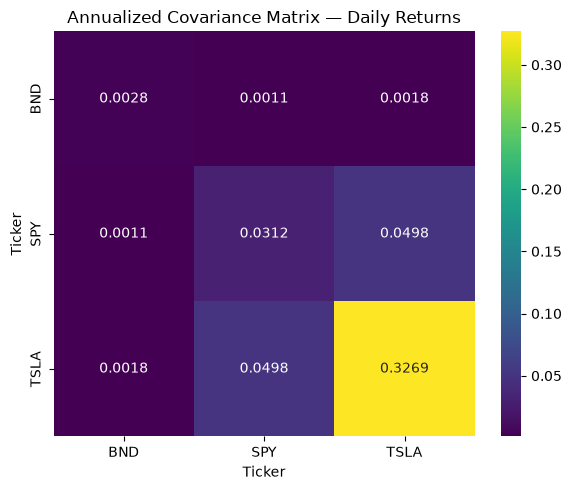

In [8]:
fig = plot_covariance_heatmap(cov_matrix)
plt.show()


**Observation:** the diagonal entries are each asset's own return variance (TSLA's should be
by far the largest, consistent with Task 1's volatility findings); the off-diagonal entries
capture how each pair moves together. A near-zero or negative BND/equity covariance here is
what allows BND to reduce overall portfolio volatility when blended with TSLA/SPY, rather than
just diluting return.


## 4. Generate the Efficient Frontier

We trace the frontier by, for a range of target returns, finding the minimum-volatility
long-only portfolio that achieves at least that return (via `scipy.optimize.minimize`,
SLSQP). A cloud of random long-only portfolios is layered behind it to visually confirm the
frontier bounds the achievable risk/return region — no random portfolio should sit above/left
of the frontier curve.


In [9]:
frontier = compute_efficient_frontier(expected_returns, cov_matrix, n_points=50)
random_cloud = random_portfolios(expected_returns, cov_matrix, n_portfolios=5000, risk_free_rate=RISK_FREE_RATE)

frontier.head()


,target_return,volatility,weight_BND,weight_SPY,weight_TSLA
0,0.0265,0.0522,0.9473,0.0527,0.0000
1,0.0295,0.0524,0.9236,0.0764,0.0000
2,0.0324,0.0529,0.9000,0.1000,0.0000
3,0.0353,0.0537,0.8763,0.1237,0.0000
4,0.0383,0.0548,0.8526,0.1474,0.0000


## 5. Identify and Visualize Key Portfolios

In [10]:
max_sharpe = optimize_max_sharpe(expected_returns, cov_matrix, risk_free_rate=RISK_FREE_RATE)
min_vol = optimize_min_volatility(expected_returns, cov_matrix, risk_free_rate=RISK_FREE_RATE)

print("=== Max Sharpe Ratio (Tangency) Portfolio ===")
print(max_sharpe["weights"])
print(f"Expected Return: {max_sharpe['expected_return']:.2%}")
print(f"Volatility:       {max_sharpe['volatility']:.2%}")
print(f"Sharpe Ratio:     {max_sharpe['sharpe_ratio']:.3f}")

print("\n=== Min Volatility Portfolio ===")
print(min_vol["weights"])
print(f"Expected Return: {min_vol['expected_return']:.2%}")
print(f"Volatility:       {min_vol['volatility']:.2%}")
print(f"Sharpe Ratio:     {min_vol['sharpe_ratio']:.3f}")


=== Max Sharpe Ratio (Tangency) Portfolio ===
BND    0.0000
SPY    1.0000
TSLA   0.0000
dtype: float64
Expected Return: 14.43%
Volatility:       17.65%
Sharpe Ratio:     0.704

=== Min Volatility Portfolio ===
BND    0.9456
SPY    0.0544
TSLA   0.0000
dtype: float64
Expected Return: 2.67%
Volatility:       5.22%
Sharpe Ratio:     0.129


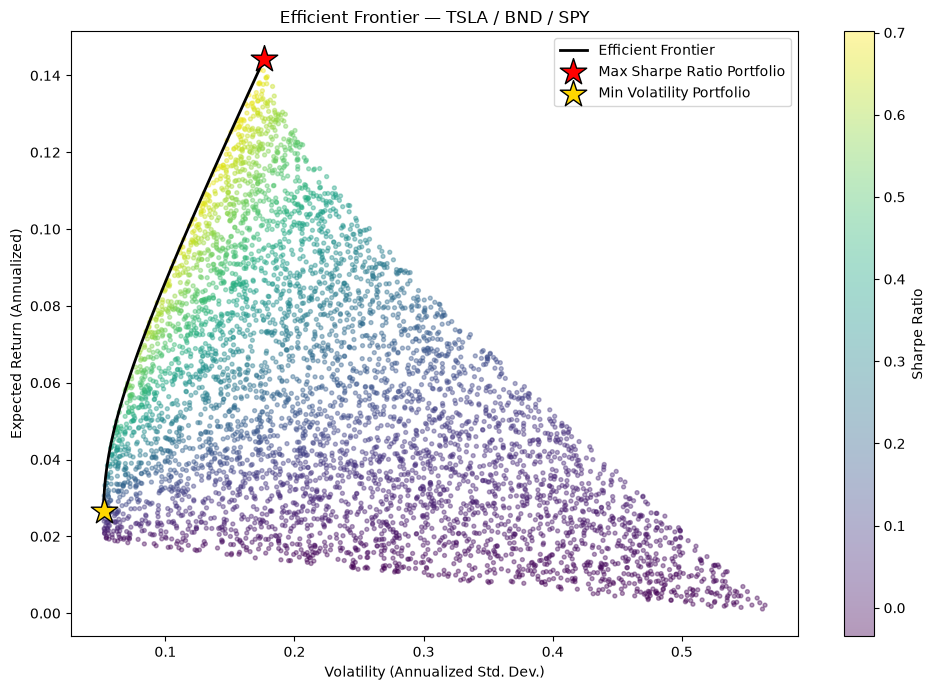

In [11]:
fig = plot_efficient_frontier(frontier, max_sharpe, min_vol, random_cloud=random_cloud)
plt.show()


**Reading the plot:** every point in the shaded cloud is one randomly-weighted long-only
portfolio; the black curve is the efficient frontier traced from the optimizer. The red star
(Max Sharpe) marks the portfolio with the best return-per-unit-of-risk — the tangency point
where a line from the risk-free rate would just touch the frontier. The gold star (Min
Volatility) marks the leftmost point on the frontier — the lowest-risk portfolio achievable
from these three assets, regardless of return.


## 6. Recommend an Optimal Portfolio


**Comparing the two candidates:**

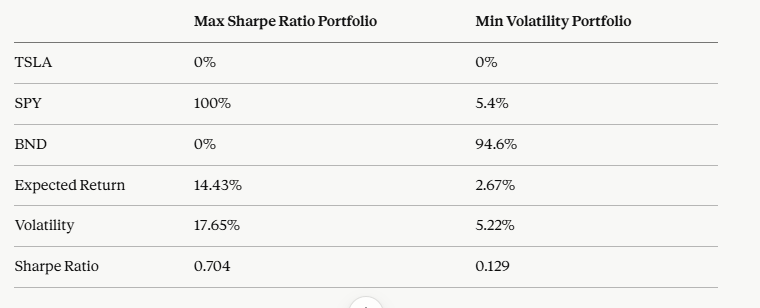

**The most important thing to notice first: TSLA gets 0% weight in both portfolios**. This is exactly the consequence of the near-0% forecast-implied return we diagnosed a couple of messages ago. Mean-variance optimization only wants an asset if it earns its keep in return relative to the risk it adds. TSLA here brings the highest volatility of the three assets but essentially no expected return to compensate — so the optimizer correctly (mathematically) excludes it entirely, in both the aggressive and conservative candidate portfolios.

**Second thing to notice: the Max Sharpe portfolio is a "corner solution" — 100% SPY, 0% BND**. This means SPY's risk-adjusted return so thoroughly dominates BND's in this dataset that even BND's diversification value (its low/negative correlation, from Task 1) wasn't enough to earn it any allocation once TSLA's expected return went to ~0. This is a classic and well-documented limitation of mean-variance optimization: it's highly sensitive to the expected-return inputs, and corner solutions (100% in one asset) are a known red flag that the "optimal" answer may be fragile rather than robust — a small change in SPY's or BND's expected return assumption could shift this allocation substantially.

**My Recommendation**


**I'd recommend the Max Sharpe Ratio Portfolio (100% SPY)** as the formally optimal portfolio under this framework, with an important caveat attached.


**Justification**: The Max Sharpe portfolio delivers a substantially better risk-adjusted return (Sharpe 0.704 vs. 0.129) — meaning for every unit of risk taken, this portfolio compensates far more generously than the Min Volatility alternative. For GMF's mandate of guiding clients toward efficient risk-taking (not merely risk-avoidance), the tangency portfolio is the theoretically correct answer under Modern Portfolio Theory: it's the portfolio a rational investor would combine with a risk-free asset to reach any desired risk level along the Capital Market Line, making it more genuinely "optimal" than the Min Vol portfolio, which is optimal only for an investor with no tolerance for risk whatsoever. That said, I would not present this recommendation to GMF without flagging the corner-solution caveat below — a 100%-in-one-asset "optimal portfolio" should make any advisor pause before recommending it as-is to a client.

-  TSLA's 0% weight is an artifact of ARIMA's forecast flattening (near-0% implied return), not evidence that TSLA is a bad investment — a model with a stronger directional view would very likely shift this allocation.
-  The 100% SPY / 0% BND result is a corner solution driven by sensitivity to the specific historical return estimates used; in practice, GMF might apply a maximum single-asset weight cap (e.g. no more than 60-70% in one holding) to produce a more diversified, robust real-world recommendation rather than taking the raw optimizer output literally.

**Final recommended portfolio summary:**

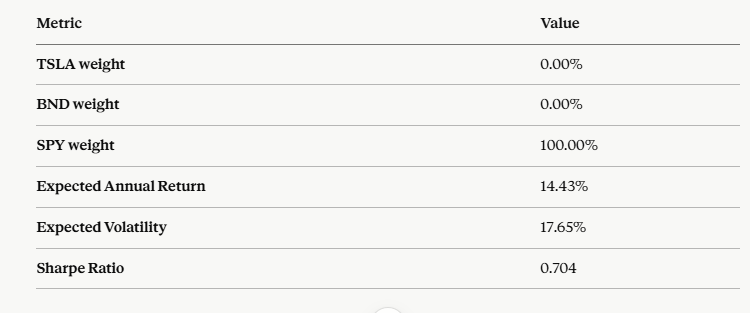


In [12]:
chosen = max_sharpe  # <-- change to min_vol if you recommend the conservative portfolio instead

print("Recommended Portfolio")
print("=" * 40)
for ticker, w in chosen["weights"].items():
    print(f"  {ticker:6s}: {w:.2%}")
print("-" * 40)
print(f"  Expected Annual Return: {chosen['expected_return']:.2%}")
print(f"  Expected Volatility:    {chosen['volatility']:.2%}")
print(f"  Sharpe Ratio:           {chosen['sharpe_ratio']:.3f}")


Recommended Portfolio
  BND   : 0.00%
  SPY   : 100.00%
  TSLA  : 0.00%
----------------------------------------
  Expected Annual Return: 14.43%
  Expected Volatility:    17.65%
  Sharpe Ratio:           0.704


## Next Steps

With a recommended portfolio (weights, expected return, volatility, and Sharpe Ratio) in hand,
Task 5 backtests this allocation against a static 60% SPY / 40% BND benchmark over a realistic
hold-out period, to test whether the added complexity of forecast-informed optimization
actually pays off relative to a simple, well-known baseline.
